
  EXECUTING EXTENDED WEAK-LENSING TRANSFORMATION MODEL
z=0.2 : A=4.3728  k0=185.01  beta=1.7711  RMS=0.00143
z=0.5 : A=8.6676  k0=158.80  beta=1.6639  RMS=0.00426
z=1.0 : A=7.9117  k0=92.81  beta=1.7655  RMS=0.00769
z=2.0 : A=15.0000  k0=120.27  beta=1.7275  RMS=0.00733
z=5.0 : A=3.2808  k0=51.07  beta=1.7795  RMS=0.00107
z=10.0: A=15.0000  k0=184.00  beta=1.6833  RMS=0.00184


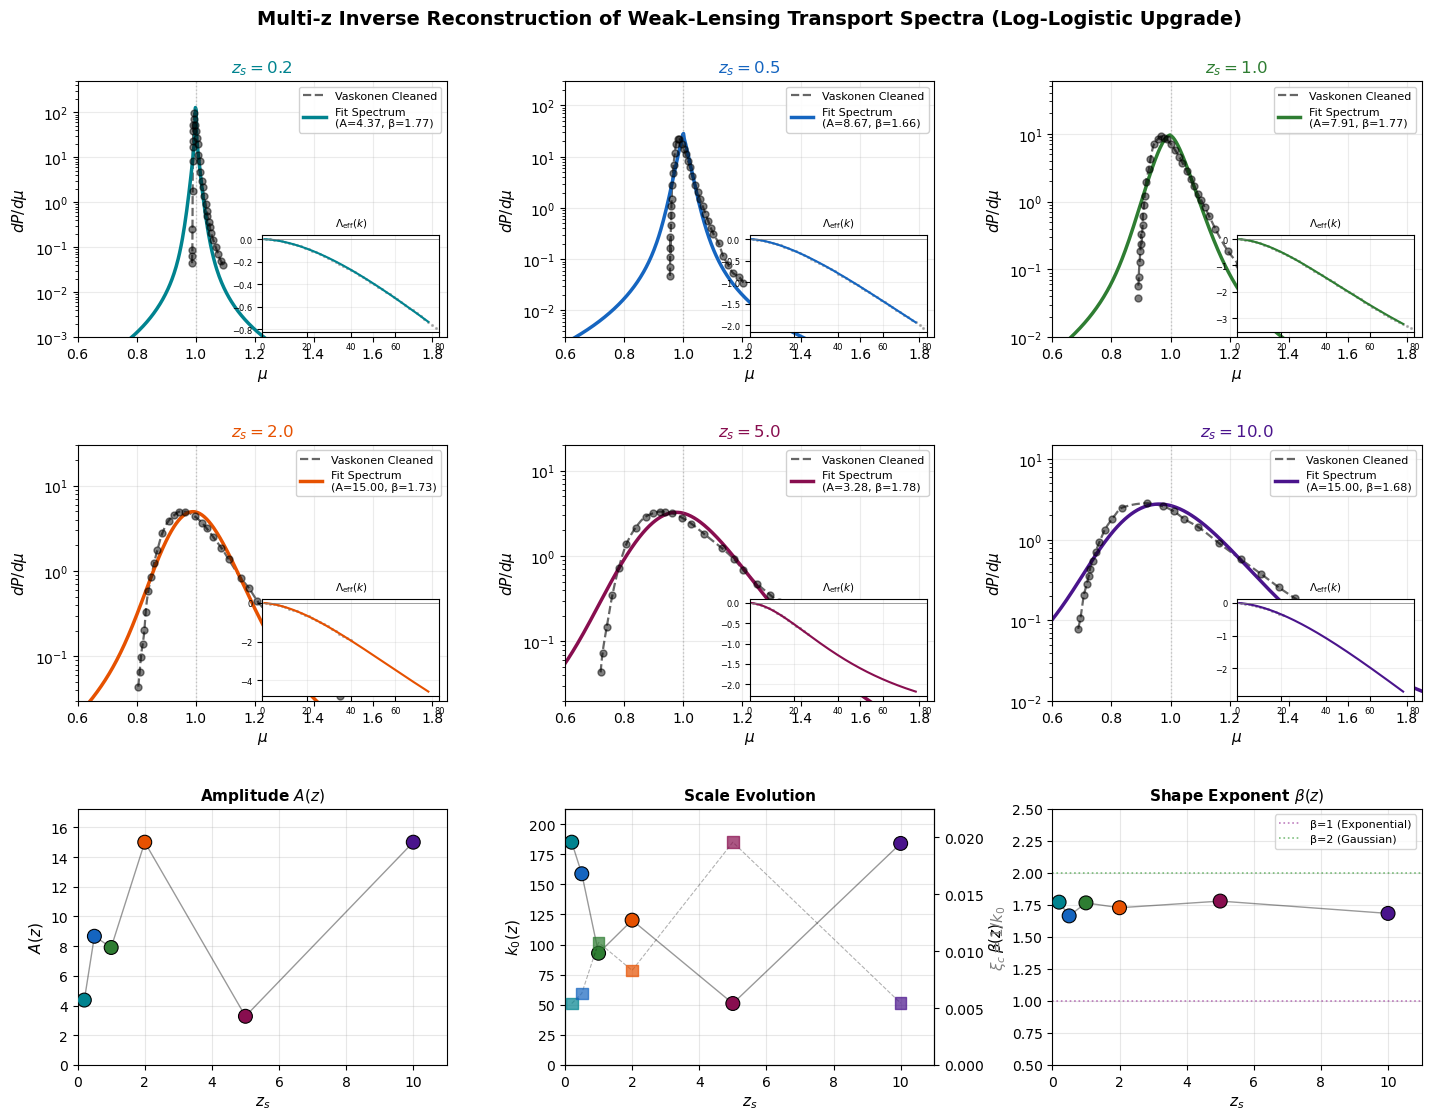

In [3]:
# ===============================================================
# WEAK-LENSING TRANSPORT RECONSTRUCTION
# PRODUCTION VERSION: 6-REDSHIFT HARDENED AUTOMATED RECONSTRUCTION
# ===============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from scipy.interpolate import PchipInterpolator
from scipy.optimize import curve_fit
from matplotlib.gridspec import GridSpec

# ===============================================================
# CONFIGURATION & SETTINGS
# ===============================================================
dx = 0.005
z_vals = [0.2, 0.5, 1.0, 2.0, 5.0, 10.0]

# Define 6 cohesive, professional scientific hex colors
colors = {
    0.2: '#00838F',   # Deep Teal
    0.5: '#1565C0',   # Strong Blue
    1.0: '#2E7D32',   # Forest Green
    2.0: '#E65100',   # Burnt Orange
    5.0: '#880E4F',   # Deep Magenta
    10.0: '#4A148C'   # Royal Purple
}

# Fine-tuned log-scale Y limits for each redshift distribution profile
ylims = {
    0.2: (0.001, 500),
    0.5: (0.003, 300),
    1.0: (0.01, 60),
    2.0: (0.03, 30),
    5.0: (0.02, 20),
    10.0: (0.01, 15)
}

# ===============================================================
# LOG-LOGISTIC (HILL-TYPE) SPECTRUM FORMULATION
# ===============================================================
def log_logistic_spectral(k, A, k0, beta):
    """
    Models the transport characteristic exponent using a flexible power law.
    Asymptotes gracefully to -A for high frequency modes.
    """
    k_norm = np.abs(k) / (k0 + 1e-15)
    return -A * (k_norm**beta) / (1.0 + k_norm**beta)

# ===============================================================
# RECONSTRUCTION ENGINE WITH ADVANCED BOUNDARY IMMUNIZATION
# ===============================================================
def reconstruct_from_csv(filepath, z, dx=0.005):
    # 1. Load data with whitespace stripping to prevent header space issues
    df = pd.read_csv(filepath, skipinitialspace=True)
    
    # 2. Critical Cleaning: Group duplicate x (mu) entries and average y (dP)
    df_clean = df.groupby('x', as_index=False).mean().sort_values('x')
    
    mu_d = df_clean['x'].values
    dP_d = df_clean['y'].values
    
    # 3. Normalize density function
    norm = np.trapezoid(dP_d, mu_d)
    dP_n = dP_d / norm

    # 4. Smooth monotonic cubic interpolation
    ilog = PchipInterpolator(mu_d, np.log(dP_n))

    # 5. Build uniform logarithmic grid
    x_u = np.arange(-1.8, 1.8 + dx, dx)
    mu_u = np.exp(x_u)
    N = len(x_u)
    dP_u = np.zeros(N)

    # Map interpolation region
    in_r = (mu_u >= mu_d[0]) & (mu_u <= mu_d[-1])
    dP_u[in_r] = np.exp(ilog(mu_u[in_r]))

    # Robust left extrapolation using polyfit over a 5-point window (prevents local noise derivative spikes)
    n_pts_L = min(5, len(mu_d))
    sl_L = np.polyfit(mu_d[:n_pts_L], np.log(dP_n[:n_pts_L]), 1)
    left = mu_u < mu_d[0]
    log_dP_left = sl_L[0] * mu_u[left] + sl_L[1]
    # Enforce standard clip limits to completely eliminate exponential overflow to inf/nan
    dP_u[left] = np.exp(np.clip(log_dP_left, -700, 700))

    # Robust right extrapolation using polyfit over a 5-point window
    n_pts_R = min(5, len(mu_d))
    sl_R = np.polyfit(np.log(mu_d[-n_pts_R:]), np.log(dP_n[-n_pts_R:]), 1)
    right = mu_u > mu_d[-1]
    log_dP_right = sl_R[0] * np.log(mu_u[right]) + sl_R[1]
    dP_u[right] = np.exp(np.clip(log_dP_right, -700, 700))

    # Final re-normalization
    dP_u /= np.trapezoid(dP_u, mu_u)

    # 6. Drift estimate: v = <ln mu> / z
    v = np.trapezoid(np.log(mu_d) * dP_n, mu_d) / z

    # 7. Convert to x-space probability: P(x) = mu * dP/dmu
    P_x = dP_u * mu_u

    # 8. Forward FFT to extract Lambda spectrum
    Fft = np.fft.fftshift(np.fft.fft(P_x)) * dx
    k_r = np.fft.fftshift(np.fft.fftfreq(N, d=dx)) * 2 * np.pi

    # Adaptive mode selection fallback loop to protect against empty ydata in low-S/N regions
    threshold = 0.02
    for attempt in range(4):
        rel = (np.abs(Fft) > threshold) & (np.abs(k_r) < 80) & (k_r > 0)
        k_p = k_r[rel]
        fm = k_p > 1
        if np.sum(fm) >= 4:
            break
        threshold /= 2.0
    else:
        # Emergency absolute fallback: take all positive modes up to scale ceiling
        rel = (k_r > 0) & (np.abs(k_r) < 80)
        k_p = k_r[rel]
        fm = k_p > 1

    Lam = np.real(np.log(Fft[rel] + 1e-15) / z)

    # 9. Spectral Fit using Log-Logistic curve
    pW, _ = curve_fit(
        log_logistic_spectral,
        k_p[fm],
        Lam[fm],
        p0=[3.0, 50.0, 1.5],
        bounds=(
            [0.05, 0.5, 0.1],
            [15.0, 450.0, 5.0]
        ),
        maxfev=20000
    )
    A_W, k0_W, beta_W = pW

    rms = np.sqrt(np.mean((Lam[fm] - log_logistic_spectral(k_p[fm], *pW))**2))

    # 10. High-resolution Forward Inverse-FT Reconstruction
    N_K = 4000
    K_MAX = 2500
    k_fwd = np.linspace(-K_MAX, K_MAX, N_K)
    dk_fwd = k_fwd[1] - k_fwd[0]

    # Hann window smoothing to eliminate boundary ringing spikes
    hann = 0.5 * (1 - np.cos(np.pi * (k_fwd + K_MAX) / K_MAX))
    Re_fit = log_logistic_spectral(k_fwd, A_W, k0_W, beta_W)
    P_hat = np.exp((Re_fit - 1j * v * k_fwd) * z) * hann

    x_fwd = np.linspace(-2.5, 2.5, 2000)
    mu_fwd = np.exp(x_fwd)

    dP_r = np.real(np.exp(1j * np.outer(x_fwd, k_fwd)) @ P_hat) * dk_fwd / (2 * np.pi) / mu_fwd
    dP_r = np.maximum(dP_r, 1e-16)
    dP_r /= np.trapezoid(dP_r, mu_fwd)

    return dict(
        A=A_W, k0=k0_W, beta=beta_W, xi_c=1/k0_W, v=v, rms=rms,
        k_p=k_p, Lam_p=Lam, mu_fwd=mu_fwd, dP_fwd=dP_r,
        mu_d=mu_d, dP_n=dP_n, ilog=ilog
    )

# ===============================================================
# DATA PROCESSING RUN
# ===============================================================
print("\n" + "="*55)
print("  EXECUTING EXTENDED WEAK-LENSING TRANSFORMATION MODEL")
print("="*55)

results = {}
for z_val in z_vals:
    z_str = str(int(z_val)) if z_val == int(z_val) else str(z_val)
    filepath = f"playground/z={z_str}.csv"
    
    if os.path.exists(filepath):
        try:
            r = reconstruct_from_csv(filepath, z_val, dx=dx)
            results[z_val] = r
            print(f"z={z_val:<4}: A={r['A']:.4f}  k0={r['k0']:.2f}  beta={r['beta']:.4f}  RMS={r['rms']:.5f}")
        except Exception as e:
            print(f"Failed to process z={z_val} due to: {str(e)}")
    else:
         # Alternative: check direct folder if notebook path varies
         filepath_alt = f"z={z_str}.csv"
         if os.path.exists(filepath_alt):
             r = reconstruct_from_csv(filepath_alt, z_val, dx=dx)
             results[z_val] = r
             print(f"z={z_val:<4}: A={r['A']:.4f}  k0={r['k0']:.2f}  beta={r['beta']:.4f}  RMS={r['rms']:.5f}")
         else:
             print(f"Warning: File not found: {filepath}")

processed_z = [z for z in z_vals if z in results]

# ===============================================================
# PRESENTATION DASHBOARD GENERATION
# ===============================================================
if processed_z:
    fig = plt.figure(figsize=(16, 12))

    # Symmetric 3x3 layout: Rows 0 & 1 for 6 PDFs, Row 2 for parameter trajectories
    gs = GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.32, height_ratios=[1, 1, 1])

    axes_pdf = [fig.add_subplot(gs[i // 3, i % 3]) for i in range(6)]
    ax_A = fig.add_subplot(gs[2, 0])
    ax_k0 = fig.add_subplot(gs[2, 1])
    ax_beta = fig.add_subplot(gs[2, 2])

    fig.suptitle(
        'Multi-z Inverse Reconstruction of Weak-Lensing Transport Spectra (Log-Logistic Upgrade)',
        fontsize=14, fontweight='bold', y=0.96
    )

    # Render PDF subplots
    for idx, z_val in enumerate(processed_z):
        ax = axes_pdf[idx]
        r = results[z_val]
        col = colors[z_val]

        # Plot cleaned digitized input data
        mu_r = np.linspace(r['mu_d'][0], r['mu_d'][-1], 400)
        ax.semilogy(mu_r, np.exp(r['ilog'](mu_r)), 'k--', lw=1.6, alpha=0.6, label='Vaskonen Cleaned')
        ax.scatter(r['mu_d'], r['dP_n'], s=25, color='k', alpha=0.5, zorder=5)

        # Plot forward-reconstructed distribution
        mk = (r['mu_fwd'] >= 0.58) & (r['mu_fwd'] <= 1.85)
        ax.semilogy(r['mu_fwd'][mk], r['dP_fwd'][mk], color=col, lw=2.5, 
                    label=f'Fit Spectrum\n(A={r["A"]:.2f}, β={r["beta"]:.2f})')

        ax.axvline(1.0, ls=':', color='gray', lw=1, alpha=0.4)
        ax.set_xlim(0.6, 1.85)
        ax.set_ylim(*ylims.get(z_val, (0.01, 100)))
        ax.set_xlabel(r'$\mu$', fontsize=11)
        ax.set_ylabel(r'$dP/d\mu$', fontsize=11)
        ax.set_title(rf'$z_s = {z_val}$', fontsize=12, fontweight='bold', color=col)
        ax.grid(True, which='major', alpha=0.25)
        ax.legend(fontsize=8, framealpha=0.9)

        # Inset axis rendering for the Lambda(k) frequency spectrum
        ax_in = ax.inset_axes([0.50, 0.02, 0.48, 0.38])
        k_ref = np.linspace(1, 75, 200)
        ax_in.plot(r['k_p'], r['Lam_p'], '.', color='gray', ms=2.5, alpha=0.5)
        ax_in.plot(k_ref, log_logistic_spectral(k_ref, r['A'], r['k0'], r['beta']), color=col, lw=1.5)
        ax_in.set_xlim(0, 80)
        ax_in.set_title(r'$\Lambda_{\rm eff}(k)$', fontsize=7.5)
        ax_in.tick_params(labelsize=6)
        ax_in.grid(True, alpha=0.2)
        ax_in.axhline(0, color='gray', lw=0.5)

    # ===============================================================
    # PARAMETER EVOLUTION VISUALIZATIONS
    # ===============================================================
    z_arr = np.array(processed_z)
    A_arr = np.array([results[z]['A'] for z in processed_z])
    k0_arr = np.array([results[z]['k0'] for z in processed_z])
    xi_arr = np.array([results[z]['xi_c'] for z in processed_z])
    bt_arr = np.array([results[z]['beta'] for z in processed_z])
    c_list = [colors[z] for z in processed_z]

    # 1. Amplitude Evolution Plot
    ax_A.scatter(z_arr, A_arr, s=100, c=c_list, zorder=5, edgecolors='k', lw=0.8)
    ax_A.plot(z_arr, A_arr, 'k-', lw=1.0, alpha=0.4)
    ax_A.set_xlabel(r'$z_s$', fontsize=11)
    ax_A.set_ylabel(r'$A(z)$', fontsize=11)
    ax_A.set_title(r'Amplitude $A(z)$', fontsize=11, fontweight='bold')
    ax_A.grid(True, alpha=0.3)
    ax_A.set_xlim(0, max(z_arr) + 1)
    ax_A.set_ylim(0, max(A_arr) * 1.15)

    # 2. Dual-Axis Scale Evolution Plot
    ax2 = ax_k0.twinx()
    ax_k0.scatter(z_arr, k0_arr, s=100, c=c_list, zorder=5, edgecolors='k', lw=0.8)
    ax_k0.plot(z_arr, k0_arr, 'k-', lw=1.0, alpha=0.4)
    ax2.scatter(z_arr, xi_arr, s=70, c=c_list, marker='s', zorder=5, alpha=0.7)
    ax2.plot(z_arr, xi_arr, 'k--', lw=0.8, alpha=0.3)
    ax_k0.set_xlabel(r'$z_s$', fontsize=11)
    ax_k0.set_ylabel(r'$k_0(z)$', fontsize=11)
    ax2.set_ylabel(r'$\xi_c=1/k_0$', fontsize=11, color='gray')
    ax_k0.set_title(r'Scale Evolution', fontsize=11, fontweight='bold')
    ax_k0.grid(True, alpha=0.3)
    ax_k0.set_xlim(0, max(z_arr) + 1)
    ax_k0.set_ylim(0, max(k0_arr) * 1.15)
    ax2.set_ylim(0, max(xi_arr) * 1.15)

    # 3. Shape Exponent Evolution Plot
    ax_beta.scatter(z_arr, bt_arr, s=100, c=c_list, zorder=5, edgecolors='k', lw=0.8)
    ax_beta.plot(z_arr, bt_arr, 'k-', lw=1.0, alpha=0.4)
    ax_beta.axhline(1.0, ls=':', color='purple', lw=1.2, alpha=0.5, label='β=1 (Exponential)')
    ax_beta.axhline(2.0, ls=':', color='green', lw=1.2, alpha=0.5, label='β=2 (Gaussian)')
    ax_beta.set_xlabel(r'$z_s$', fontsize=11)
    ax_beta.set_ylabel(r'$\beta(z)$', fontsize=11)
    ax_beta.set_title(r'Shape Exponent $\beta(z)$', fontsize=11, fontweight='bold')
    ax_beta.grid(True, alpha=0.3)
    ax_beta.set_xlim(0, max(z_arr) + 1)
    ax_beta.set_ylim(0.5, max(max(bt_arr) * 1.15, 2.5))
    ax_beta.legend(fontsize=8, loc='upper right')

    plt.subplots_adjust(bottom=0.08, top=0.90, left=0.08, right=0.92)
    plt.show()
else:
    print("Error: No redshift data files were processed successfully.")